In [16]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
import os
import fiona
from geopy.distance import geodesic

In [17]:
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")

In [18]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

In [19]:
doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

<ipython-input-19-d321f24f92aa>:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  doubs_data['centroid'] = doubs_data.geometry.centroid


In [20]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

print(doubs_data.head())

            hex_id raison_sortie          date_debut            date_fin  \
0  871f820aaffffff      NATURELS 2014-10-02 14:08:53 2014-10-02 19:54:25   
1  871f82d61ffffff      NATURELS 2014-10-03 19:33:59 2014-10-03 19:55:31   
2  871f82d61ffffff      NATURELS 2014-10-04 19:24:49 2014-10-04 19:59:02   
3  871f82d4dffffff      NATURELS 2014-10-04 20:10:43 2014-10-04 20:42:34   
4  871f82700ffffff      NATURELS 2014-10-05 12:57:52 2014-10-05 13:24:24   

   label    year       date           departement  duree_minutes  \
0    1.0  2014.0 2014-10-02  departement-25-doubs     345.533333   
1    1.0  2014.0 2014-10-03  departement-25-doubs      21.533333   
2    1.0  2014.0 2014-10-04  departement-25-doubs      34.216667   
3    1.0  2014.0 2014-10-04  departement-25-doubs      31.850000   
4    1.0  2014.0 2014-10-05  departement-25-doubs      26.533333   

                                            geometry  ... water       tree  \
0  POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...  ..

Dimensions du DataFrame :
(2965, 65)

Info sur les types de données et les valeurs manquantes :
<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 2965 entries, 0 to 2964
Data columns (total 65 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   hex_id                 2965 non-null   object         
 1   raison_sortie          2965 non-null   object         
 2   date_debut             2965 non-null   datetime64[ns] 
 3   date_fin               2965 non-null   datetime64[ns] 
 4   label                  2965 non-null   float64        
 5   year                   2965 non-null   float64        
 6   date                   2965 non-null   datetime64[ns] 
 7   departement            2965 non-null   object         
 8   duree_minutes          2965 non-null   float64        
 9   geometry               2965 non-null   geometry       
 10  duree                  2965 non-null   timedelta64[ns]
 11  cent

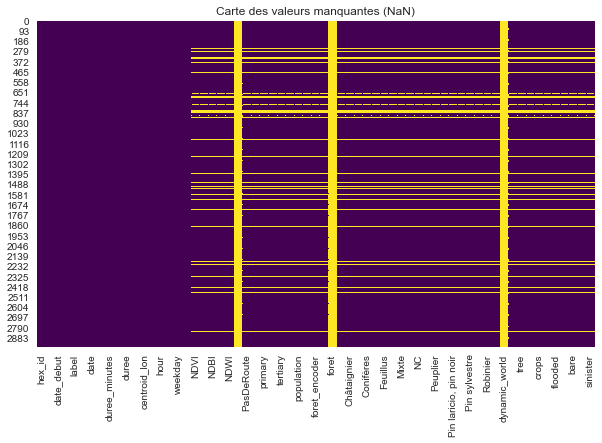


Nombre de valeurs manquantes (NaN) par colonne :
hex_id             0
raison_sortie      0
date_debut         0
date_fin           0
label              0
                ... 
flooded          286
built            286
bare             286
snow             286
sinister         286
Length: 65, dtype: int64


In [21]:
print("Dimensions du DataFrame :")
print(doubs_data.shape)

print("\nInfo sur les types de données et les valeurs manquantes :")
print(doubs_data.info())

plt.figure(figsize=(10, 6))
sns.heatmap(doubs_data.isnull(), cbar=False, cmap='viridis')
plt.title("Carte des valeurs manquantes (NaN)")
plt.show()

print("\nNombre de valeurs manquantes (NaN) par colonne :")
print(doubs_data.isnull().sum())

In [22]:
nan_percentage = doubs_data.isnull().mean() * 100

cols_to_keep = nan_percentage[nan_percentage <= 80].index

data_clean = doubs_data[cols_to_keep]

print("\nDimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :")
print(data_clean.shape)

print("\nColonnes restantes après nettoyage :")
print(data_clean.columns)


Dimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :
(2965, 62)

Colonnes restantes après nettoyage :
Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry', 'duree', 'centroid',
       'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'scale0',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister'],
      dtype='object')


In [23]:
data_clean = data_clean.dropna()

print("\nVérification des NaN après suppression des lignes dans data_clean :")
print(data_clean.isnull().sum())

print("\nDimensions du DataFrame data_clean après suppression des NaN :")
print(data_clean.shape)


Vérification des NaN après suppression des lignes dans data_clean :
hex_id           0
raison_sortie    0
date_debut       0
date_fin         0
label            0
                ..
flooded          0
built            0
bare             0
snow             0
sinister         0
Length: 62, dtype: int64

Dimensions du DataFrame data_clean après suppression des NaN :
(2679, 62)


In [25]:
data_clean = data_clean.drop(columns=['raison_sortie', 'label', 'geometry', 'date', 'scale0', 'date_debut', 'date_fin', 'year', 'sinister', 'departement', 'centroid', 'hour', 'weekday', 'month'])

In [41]:
data_clean.columns

Index(['hex_id', 'duree_minutes', 'centroid_lon', 'centroid_lat', 'NDVI',
       'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary',
       'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow'],
      dtype='object')

In [26]:
data_clean = data_clean.groupby('hex_id').mean().reset_index()
print(data_clean.head())

            hex_id  duree_minutes  centroid_lon  centroid_lat      NDVI  \
0  871f80492ffffff     117.325000      6.350198     47.477082  0.720443   
1  871f80493ffffff      79.483333      6.381746     47.480996  0.739361   
2  871f80498ffffff     160.133333      6.444873     47.488800  0.785204   
3  871f8049affffff      65.383333      6.431903     47.468880  0.778036   
4  871f8049cffffff      89.400000      6.426270     47.504821  0.751272   

       NDMI      NDBI      NDSI      NDWI  PasDeRoute  ...  Sapin, épicéa  \
0  0.145452 -0.145452 -0.593620 -0.672639   96.116627  ...       0.000000   
1  0.162564 -0.162564 -0.599609 -0.688388   95.966830  ...       0.728735   
2  0.193932 -0.193932 -0.627573 -0.728378   97.701871  ...       5.035791   
3  0.189057 -0.189057 -0.623016 -0.721208   96.609318  ...       0.941856   
4  0.175163 -0.175163 -0.599002 -0.693667   96.231629  ...       0.000000   

      water       tree      grass     crops     shrub   flooded     built  \
0  0.0125

In [43]:
gdf = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")

gdf.head

<bound method NDFrame.head of      id_pg                    sous_type cs_cod                 nom  \
0   840642  Centre de Secours Principal  25155        BESANCON EST   
1   840674            Centre de Secours  25706     PREMIER PLATEAU   
2   840713                          CPI  25703  PLATEAU DE BLAMONT   
3   840644  Centre de Secours Principal  25462          PONTARLIER   
4   840712                          CPI  25004         ABBEVILLERS   
..     ...                          ...    ...                 ...   
68  840701                          CPI  25494           ROCHEJEAN   
69  840671            Centre de Secours  25259              FRASNE   
70  840683                 CPI Renforcé  25254          LES FOURGS   
71  840722                CPI communaux  25346          LONGEVILLE   
72  840719                CPI communaux  25157  LA CLUSE ET MIJOUX   

          compagnie                        geometry  
0          Besançon  POINT (931721.900 6689543.170)  
1   Baume-les-Dames  

In [48]:
gdf_2 = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")

gdf_2.head

<bound method NDFrame.head of       id                  nom   num  \
0    1.0             Besançon   2.0   
1    2.0      Baume-les-Dames   4.0   
2    3.0               Ornans   3.0   
3    4.0           Pontarlier  11.0   
4    5.0            Mont d'Or  12.0   
5    6.0          Montbéliard   6.0   
6    7.0              Morteau  10.0   
7    8.0             Valdahon   9.0   
8    9.0               Maiche   8.0   
9   10.0  L'Isle-sur-le-Doubs   5.0   
10  11.0        Pont-de-Roide   7.0   
11  12.0            Saint-Vit   1.0   

                                             geometry  
0   POLYGON ((925443.770 6696539.450, 925467.810 6...  
1   POLYGON ((954795.640 6692811.660, 954669.790 6...  
2   POLYGON ((941339.430 6661936.250, 941405.150 6...  
3   POLYGON ((950737.550 6645163.230, 950713.240 6...  
4   MULTIPOLYGON (((956091.400 6629683.490, 956016...  
5   POLYGON ((995150.460 6707740.100, 995272.470 6...  
6   POLYGON ((974073.160 6676847.160, 974391.890 6...  
7   POLYGON ((